In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import numpy as np

In [ ]:
!pip install geopandas
!pip install pykrige

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 10.5 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import os
import tensorflow as tf
from keras import layers, models
from sklearn.pipeline import Pipeline
import pykrige #biblioteca de geoestadística
import pykrige.kriging_tools as kt #herramientas para exportar e importar archivos .asc con biblioteca PyKrige
from pykrige.ok import OrdinaryKriging #Kriging Ordinario con PyKrige

forecasting

In [ ]:
path="/content/drive/MyDrive/investigacion/15D/pruebadatasetLc"
df=pd.read_csv(path+"/landsat2003-01-01.csv")
df.head()

,lat,lon,band1,band2,band3,band4,band5,band6,band7,irradiance
0,-8789850.0,184950.0,0.101755,0.078818,0.051683,0.264549,0.129877,296.541341,0.043120,204.986188
1,-8784900.0,174600.0,0.103636,0.081440,0.051834,0.276332,0.131768,296.468388,0.043376,202.845077
2,-8775000.0,164700.0,0.106230,0.095642,0.069535,0.328565,0.178510,295.296542,0.075029,208.215425
3,-8775000.0,169650.0,0.106100,0.085670,0.058951,0.267595,0.123353,294.432919,0.046396,200.875290
4,-8775000.0,174600.0,0.105858,0.082105,0.051419,0.279088,0.128134,296.558853,0.040179,200.495335


In [ ]:
min_lat=df["lat"].min()
max_lat=df["lat"].max()
min_lon=df["lon"].min()
max_lon=df["lon"].max()
print(min_lat,max_lat,min_lon,max_lon)

-8789850.0 -8554950.0 45000.0 294750.0


In [ ]:
lat=df['lat'].unique()
lon=df['lon'].unique()

lat=np.sort(lat)
lon=np.sort(lon)
dif_lat=np.diff(lat)
dif_lon=np.diff(lon)

min_dif_lat=np.min(dif_lat)
min_dif_lon=np.min(dif_lon)

print(min_dif_lat,min_dif_lon)

4950.0 4950.0


In [ ]:

def get_images(df,max_lat,min_lat,max_lon,min_lon):
  rows = int(np.ceil((max_lat - min_lat) / 4950)) + 1
  cols = int(np.ceil((max_lon - min_lon) / 4950)) + 1
  matrix_b1 = np.zeros((cols, rows))
  matrix_b2 = np.zeros((cols, rows))
  matrix_b3 = np.zeros((cols, rows))
  matrix_b4 = np.zeros((cols, rows))
  matrix_b5 = np.zeros((cols, rows))
  matrix_b6 = np.zeros((cols, rows))
  matrix_b7 = np.zeros((cols, rows))
  matrix_b8 = np.zeros((cols, rows))
  matrix_irradiance = np.zeros((cols, rows))

  # Llenar la matriz con los valores de irradiancia
  for index, row in df.iterrows():
      lat_index = int(np.floor((row['lat'] - min_lat) / 4950))
      lon_index = int(np.floor((max_lon-row['lon']) / 4950))
      if 0 <= lat_index < rows and 0 <= lon_index < cols:
        matrix_b1[lon_index, lat_index] = row['band1']
        matrix_b2[lon_index, lat_index] = row['band2']
        matrix_b3[lon_index, lat_index] = row['band3']
        matrix_b4[lon_index, lat_index] = row['band4']
        matrix_b5[lon_index, lat_index] = row['band5']
        matrix_b6[lon_index, lat_index] = row['band6']
        matrix_b7[lon_index, lat_index] = row['band7']
        matrix_b8[lon_index, lat_index] = row['irradiance']

        matrix_irradiance[lon_index, lat_index] = row['irradiance']

  satelital_image = np.stack((matrix_b1, matrix_b2, matrix_b3, matrix_b4, matrix_b5, matrix_b6, matrix_b7), axis=-1)
  return satelital_image,matrix_irradiance

def get_dataframe(df,matrix,max_lat,min_lat,max_lon,min_lon):
  rows = int(np.ceil((max_lat - min_lat) / 4950)) + 1
  cols = int(np.ceil((max_lon - min_lon) / 4950)) + 1
  lat=[]
  lon=[]
  irradiance=[]
  # Llenar la matriz con los valores de irradiancia
  for index, row in df.iterrows():
      lat_index = int(np.floor((row['lat'] - min_lat) / 4950))
      lon_index = int(np.floor((max_lon-row['lon']) / 4950))
      if 0 <= lat_index < rows and 0 <= lon_index < cols:
        lat.append(row['lat'])
        lon.append(row['lon'])
        irradiance.append(matrix[lon_index, lat_index])

  df_result=pd.DataFrame({'latitude':lat,'longitude':lon,'irradiance':irradiance})
  return df_result

In [ ]:
satelital_image,matrix_irradiance=get_images(df,max_lat,min_lat,max_lon,min_lon)
satelital_image.shape,matrix_irradiance.shape

((52, 49, 7), (52, 49))

In [ ]:
#nombre dce columnas
print(df.columns)

Index(['lat', 'lon', 'band1', 'band2', 'band3', 'band4', 'band5', 'band6',
       'band7', 'irradiance'],
      dtype='object')


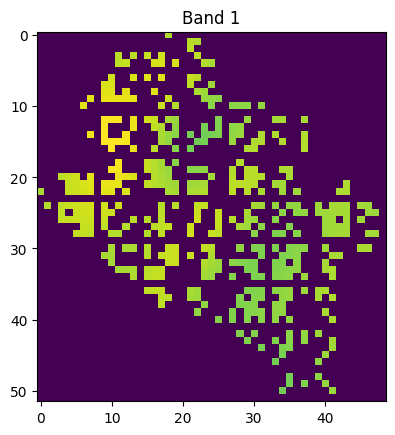

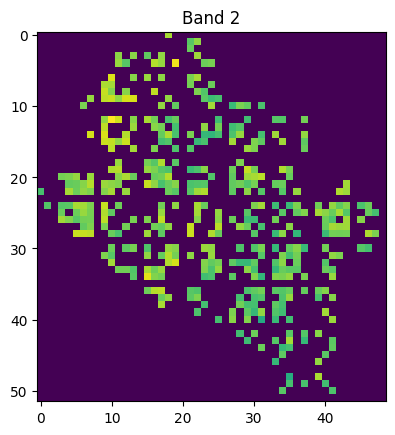

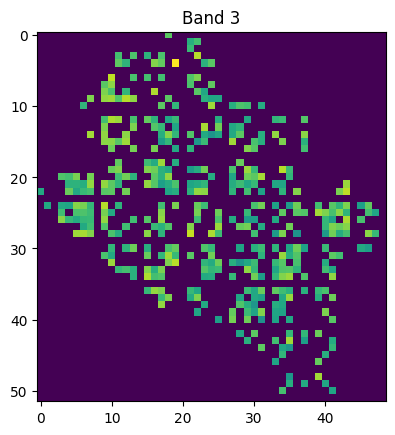

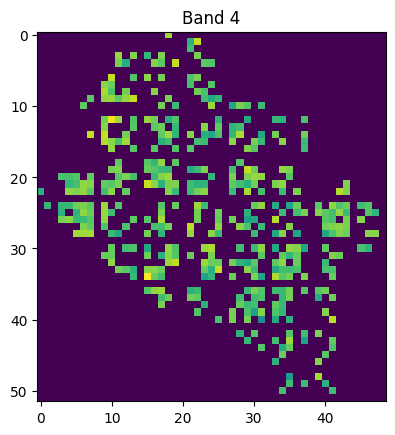

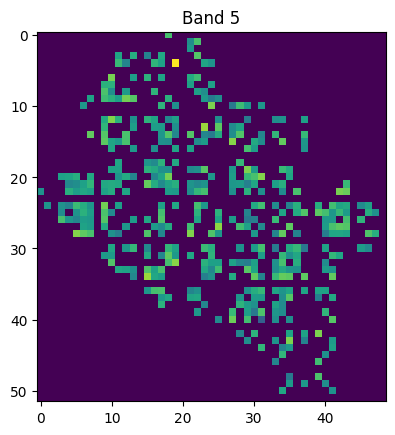

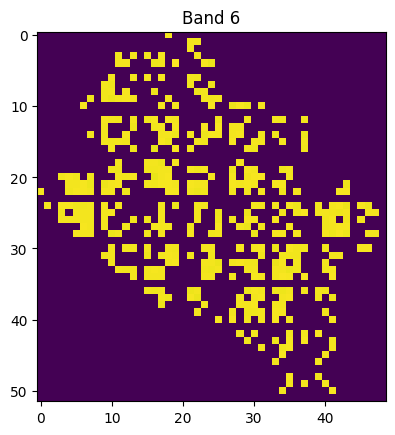

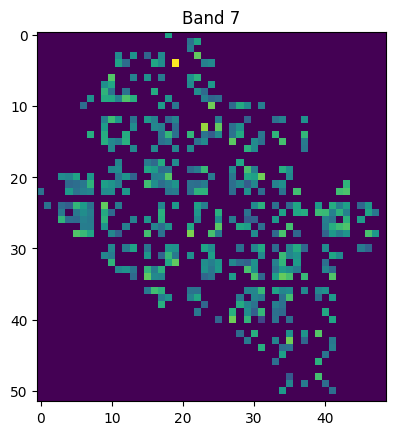

In [ ]:
for i in range(satelital_image.shape[2]):
  plt.title(f"Band {i+1}")
  plt.imshow(satelital_image[:,:,i])
  plt.show()

In [ ]:
X=[]
y=[]
dates=[]
for filename in os.listdir(path):
  print(filename)
  if filename.endswith(".csv"):
    print("read file")
    df=pd.read_csv(path+"/"+filename)
    dates.append(filename.split(".")[0])
    print("get images 2 dataframe")
    satelital_image,matrix_irradiance=get_images(df,max_lat,min_lat,max_lon,min_lon)
    print("append images")
    X.append(satelital_image)
    y.append(matrix_irradiance)


landsat2003-01-01.csv
read file
get images 2 dataframe
append images
landsat2003-01-16.csv
read file
get images 2 dataframe
append images
landsat2003-01-31.csv
read file
get images 2 dataframe
append images
landsat2003-02-15.csv
read file
get images 2 dataframe
append images
landsat2003-03-02.csv
read file
get images 2 dataframe
append images
landsat2003-03-17.csv
read file
get images 2 dataframe
append images
landsat2003-04-01.csv
read file
get images 2 dataframe
append images
landsat2003-04-16.csv
read file
get images 2 dataframe
append images
landsat2003-05-01.csv
read file
get images 2 dataframe
append images
landsat2003-05-16.csv
read file
get images 2 dataframe
append images
landsat2003-05-31.csv
read file
get images 2 dataframe
append images
landsat2003-06-15.csv
read file
get images 2 dataframe
append images
landsat2003-06-30.csv
read file
get images 2 dataframe
append images
landsat2003-07-15.csv
read file
get images 2 dataframe
append images
landsat2003-07-30.csv
read file
ge

In [ ]:
df

,lat,lon,band1,band2,band3,band4,band5,band6,band7,irradiance
0,-8789850.0,184950.0,0.101974,0.099634,0.073342,0.360860,0.195844,296.056202,0.081359,209.522754
1,-8784900.0,174600.0,0.103857,0.089601,0.055783,0.352965,0.163490,296.313819,0.055147,202.118384
2,-8775000.0,164700.0,0.106647,0.092367,0.066178,0.321952,0.152637,292.896598,0.064372,208.465556
3,-8775000.0,169650.0,0.106259,0.099159,0.070739,0.349668,0.172360,294.501486,0.067822,208.093206
4,-8775000.0,174600.0,0.105815,0.085270,0.061636,0.277106,0.134790,294.660504,0.051084,201.281203
...,...,...,...,...,...,...,...,...,...,...
429,-8559900.0,154800.0,0.100841,0.076637,0.049078,0.251425,0.106560,296.055115,0.035541,215.446933
430,-8559900.0,169650.0,0.101604,0.087636,0.064459,0.293446,0.138048,292.643563,0.058337,218.571685
431,-8559900.0,174600.0,0.102107,0.085708,0.058372,0.302789,0.151979,295.918571,0.055898,222.553519
432,-8554950.0,154800.0,0.100705,0.075834,0.048298,0.229172,0.100763,296.017984,0.034161,215.414607


In [ ]:
new_dates = []
for date in dates:
  new_dates.append(date.replace("dataset","").replace("landsat", ""))

In [ ]:
#convert str to date
from datetime import datetime
new_dates = [datetime.strptime(date, '%Y-%m-%d') for date in new_dates]

In [ ]:
X=np.array(X)

In [ ]:
y=np.array(y)

In [ ]:
X.shape,y.shape

((293, 52, 49, 7), (293, 52, 49))

In [ ]:
new_dates=np.array(new_dates)
index=np.argsort(new_dates)
X=X[index]
y=y[index]

In [67]:
#min max scaler
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
X = scaler.fit_transform(X.reshape(-1, X.shape[-1])).reshape(X.shape)
X.shape

(293, 52, 49, 7)

In [ ]:
y=scaler.fit_transform(y.reshape(-1, 1)).reshape(y.shape)
y.shape

(293, 52, 49)

In [ ]:
X.min(),X.max(),y.min(),y.max()

(np.float64(0.0), np.float64(1.0), np.float64(0.0), np.float64(1.0))

windows


In [ ]:
#forecasting window
def window(X,y,v):
  yt=y[v:]
  Xt=[]
  for i in range(X.shape[0]-v):
    Xt.append(X[i:i+v])

  return np.array(Xt),yt

In [ ]:
Xt,yt=window(X,y,7)
Xt.shape,yt.shape

((286, 7, 52, 49, 7), (286, 52, 49))

In [ ]:
Xt.shape[1:]

(7, 52, 49, 7)

In [ ]:
Xt.shape

(286, 7, 52, 49, 7)

In [ ]:
Xtrain=Xt[:int(0.8*Xt.shape[0])]
ytrain=yt[:int(0.8*yt.shape[0])]

Xtest=Xt[int(0.8*Xt.shape[0]):]
ytest=yt[int(0.8*yt.shape[0]):]

In [ ]:
X_train=Xtrain[:int(0.8*Xtrain.shape[0])]
y_train=ytrain[:int(0.8*ytrain.shape[0])]

X_test=Xtrain[int(0.8*Xtrain.shape[0]):]
y_test=ytrain[int(0.8*ytrain.shape[0]):]

model

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, ConvLSTM2D, Conv2D, BatchNormalization, Dropout

inputs = Input(shape=(Xt.shape[1:]))  # ventana temporal, alto, ancho, canales

x = ConvLSTM2D(filters=32, kernel_size=(3, 3), padding='same', return_sequences=False, activation='relu')(inputs)
x = BatchNormalization()(x)             # Normalización para estabilizar
x = Dropout(0.3)(x)                     # Dropout para evitar sobreajuste

x = Conv2D(filters=16, kernel_size=(3, 3), padding='same', activation='relu')(x)
x = BatchNormalization()(x)             # Otra capa de normalización
x = Dropout(0.3)(x)                     # Más dropout

outputs = Conv2D(filters=1, kernel_size=(3, 3), padding='same', activation='linear')(x)

model = Model(inputs, outputs)
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 7, 52, 49, 7)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_lstm2d (ConvLSTM2D)        │ (None, 52, 49, 32)     │        45,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 52, 49, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 52, 49, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 52, 49, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 52, 49, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 52, 49, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 52, 49, 1)      │           145 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,017 (195.38 KB)

 Trainable params: 49,921 (195.00 KB)

 Non-trainable params: 96 (384.00 B)

In [ ]:
path="/content/drive/MyDrive/investigacion/windows"


In [ ]:
#early stopping
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
#metrics
from tensorflow.keras.metrics import MeanAbsoluteError

early_stopping = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=10, min_lr=1e-8)
checkpoint= ModelCheckpoint(filepath=path+'model.keras', monitor='val_loss', save_best_only=True)

model.fit(Xtrain, ytrain, epochs=1000, batch_size=32,validation_data=(X_test,y_test), callbacks=[early_stopping, reduce_lr,checkpoint])

Epoch 1/1000
8/8 ━━━━━━━━━━━━━━━━━━━━ 47s 5s/step - loss: 1.9663 - mae: 1.0502 - val_loss: 0.1039 - val_mae: 0.1579 - learning_rate: 0.0010
Epoch 2/1000
8/8 ━━━━━━━━━━━━━━━━━━━━ 81s 5s/step - loss: 1.1023 - mae: 0.7899 - val_loss: 0.1110 - val_mae: 0.1627 - learning_rate: 0.0010
Epoch 3/1000
8/8 ━━━━━━━━━━━━━━━━━━━━ 43s 5s/step - loss: 0.8395 - mae: 0.6870 - val_loss: 0.0979 - val_mae: 0.1578 - learning_rate: 0.0010
Epoch 4/1000
8/8 ━━━━━━━━━━━━━━━━━━━━ 42s 5s/step - loss: 0.6927 - mae: 0.6237 - val_loss: 0.0874 - val_mae: 0.1504 - learning_rate: 0.0010
Epoch 5/1000
8/8 ━━━━━━━━━━━━━━━━━━━━ 40s 5s/step - loss: 0.5928 - mae: 0.5767 - val_loss: 0.0860 - val_mae: 0.1450 - learning_rate: 0.0010
Epoch 6/1000
8/8 ━━━━━━━━━━━━━━━━━━━━ 40s 5s/step - loss: 0.5124 - mae: 0.5356 - val_loss: 0.0870 - val_mae: 0.1437 - learning_rate: 0.0010
Epoch 7/1000
8/8 ━━━━━━━━━━━━━━━━━━━━ 41s 5s/step - loss: 0.4525 - mae: 0.5019 - val_loss: 0.0835 - val_mae: 0.1387 - learning_rate: 0.0010
Epoch 8/1000
8/8 ━━━

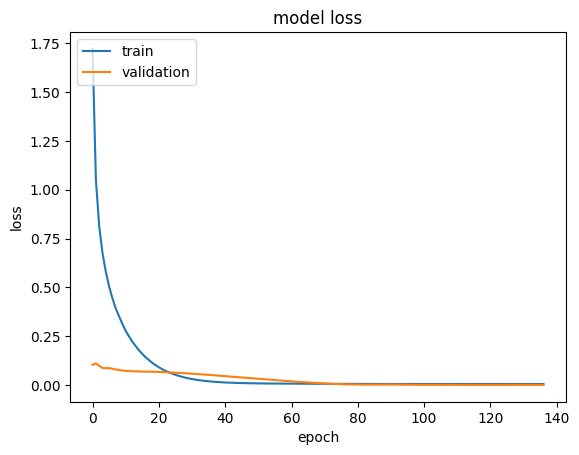

In [ ]:
#plot history
import matplotlib.pyplot as plt
plt.plot(model.history.history['loss'])
plt.plot(model.history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper left')


In [ ]:
model.evaluate(Xtest,ytest)

2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step - loss: 6.0040e-04 - mae: 0.0160


[0.0005986482137814164, 0.015949342399835587]

In [ ]:
ytest.shape

(58, 52, 49)

In [ ]:
#r2 score
from sklearn.metrics import r2_score
n=ytest.shape[0]
y_pred = model.predict(Xtest)
y_pred[ytest==0]=0
r2_score(ytest.reshape(n,-1), y_pred.reshape(n,-1))

2/2 ━━━━━━━━━━━━━━━━━━━━ 4s 1s/step


0.21697099686134272

In [ ]:
plt.subplot(1, 2, 1)
plt.title('Original')
plt.imshow(ytest[90])
plt.subplot(1, 2, 2)
plt.title('Predicted')
plt.imshow(y_pred[90])
plt.show()